In [1]:
import numpy as np
import pickle, os 
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
import pandas as pd  

In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand
atlas_name = 'glasser' 
# atlas_name = 'yeo17' 

# defining ROIs
# large_ROI = 'PFC'
# large_ROI = 'visual'
# large_ROI = 'somatosensory'
large_ROI = 'parietal'

resultsPath = os.path.join(mainResultsPath, 'START_B4_parcellation_sanity', dataset_name, atlas_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

output = dict()
PKL_output = os.path.join(resultsPath, f'{dataset_name}_{large_ROI}_output.pkl')

In [3]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', dataset_name, atlas_name, f'output_{large_ROI}.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    U_indiv_label = output_indiv['indiv_parcellation']  # n_subjects x P
    U_group_label = output_indiv['group_parcellation']
    V = output_indiv['V'].T                             # n_parcels x n_conditions

In [4]:
import sys

np.set_printoptions(threshold=sys.maxsize)

In [5]:
n_subjects, P = U_indiv_label.shape
n_parcels = V.shape[1]

# count the number of parcels for each individual
n_parcels_per_indiv = []
n_vertices_per_parcel = []
for subjI in np.arange(n_subjects):
    vals, counts = np.unique(U_indiv_label[subjI], return_counts=True)
    n_parcels_per_indiv.append(len(vals))
    n_vertices_per_parcel.append(counts) 

n_parcels_per_indiv = np.array(n_parcels_per_indiv)
n_vertices_per_parcel = np.array(n_vertices_per_parcel)

print(n_parcels_per_indiv)


pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) 

df = pd.DataFrame(n_vertices_per_parcel)
display(df) 

[12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12 12]


,0,1,2,3,4,5,6,7,8,9,10,11
0,106,253,602,236,383,240,270,566,251,100,331,56180
1,106,523,646,262,303,165,435,293,146,188,271,56180
2,106,948,299,262,613,153,182,120,254,316,85,56180
3,106,247,448,236,325,269,308,591,241,54,513,56180
4,106,346,120,107,210,497,545,73,918,200,216,56180
5,106,659,210,538,340,217,207,96,145,604,216,56180
6,106,581,320,285,301,83,512,242,202,267,439,56180
7,106,411,433,171,211,84,276,436,549,227,434,56180
8,106,164,394,343,186,401,326,650,252,250,266,56180
9,106,281,66,174,201,541,435,182,812,264,276,56180


In [6]:
# load V compute similarity between each pair of parcels
V_simmats = np.corrcoef(V)

Text(0, 0.5, 'parcels')

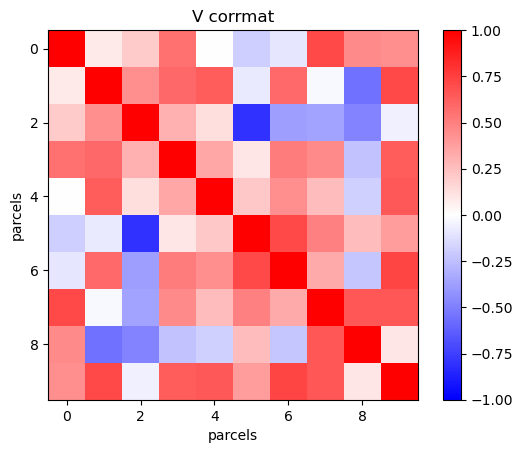

In [7]:
JPG_V_corrmat = os.path.join(resultsPath, f'V_corrmat_{atlas_name}.jpg')
fig, ax = plt.subplots(1, 1)
im = ax.imshow(V_simmats, cmap='bwr', vmin=-1, vmax=1)
ax.set_aspect('equal')
plt.colorbar(im)
ax.set_title(f'V corrmat')
ax.set_xlabel('parcels')
ax.set_ylabel('parcels')

In [8]:
output['V'] = V
output['V_simmats'] = V_simmats
output['n_parcels_per_indiv'] = n_parcels_per_indiv
output['n_vertices_per_parcel'] = n_vertices_per_parcel

In [9]:
plt.savefig(JPG_V_corrmat, dpi=400, format='jpg')

with open(PKL_output, 'wb') as pf:
    pickle.dump(output, pf)

<Figure size 640x480 with 0 Axes>